<a href="https://www.kaggle.com/code/sanchitmark/natural-selection-for-classifiers?scriptVersionId=331450737" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Survival of the Fittest: Evolving Decision
### *An Evolutionary Computation Approach to Classification*

---

##  Introduction

Most machine learning models rely on **gradient-based optimization** to learn decision boundaries.
However, nature solves complex optimization problems **without gradients**, using evolution.

Inspired by evolutionary design methods (such as NASA’s antenna experiments),  
this notebook explores whether **Genetic Algorithms (GA)** can evolve **effective and non-intuitive decision boundaries**
for classification tasks.

Instead of training a neural network using backpropagation, we:
- Project data into 2D using **PCA**
- Define a parameterized decision boundary
- Use **Genetic Algorithms** to evolve its shape
- Visually observe how classification performance improves across generations

---

## Objectives

- Apply Genetic Algorithms to evolve decision boundaries
- Visualize evolutionary improvement generation by generation
- Demonstrate meaningful learning without gradient descent
- Keep the experiment lightweight and reproducible

---

##  Dataset

We use the **Wine dataset**, a classic multi-class classification problem with:
- 178 samples
- 13 numerical features
- 3 target classes

The dataset is loaded directly from `sklearn.datasets` to ensure simplicity and reproducibility.

---


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score

np.random.seed(42)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")
 
print("Dataset shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

X.head()


Dataset shape: (178, 13)

Class distribution:
class
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")


Feature scaling completed.


##  Dimensionality Reduction with PCA

The Wine dataset has **13 features**, which makes direct visualization impossible.
To observe and evolve decision boundaries, we project the data into **two dimensions** using
**Principal Component Analysis (PCA)**.

PCA:
- Preserves as much variance as possible
- Creates orthogonal components
- Allows us to visualize class separation in 2D

This 2D space will serve as the **environment** in which evolution takes place.


In [4]:
# Apply PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca, 
    columns=["PC1", "PC2"]
)
pca_df["class"] = y

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()


Explained variance ratio: [0.36198848 0.1920749 ]


,PC1,PC2,class
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


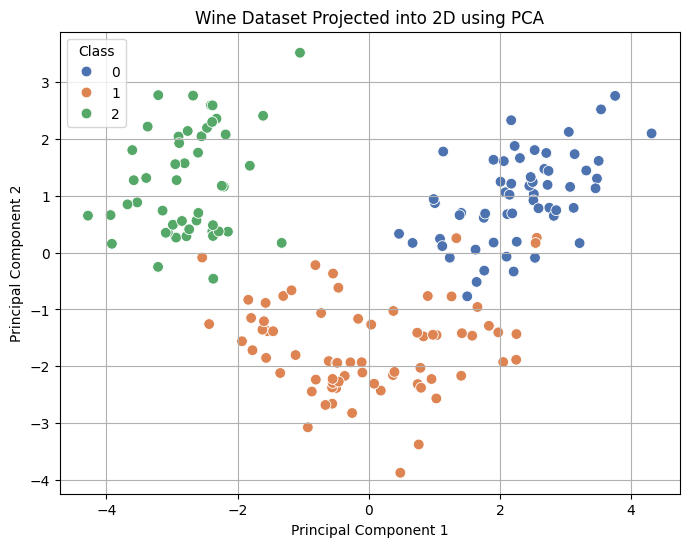

In [5]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="class",
    palette="deep",
    s=60
)

plt.title("Wine Dataset Projected into 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Class")
plt.grid(True)
plt.show()

##  Interpretation

From the PCA plot, we can observe:
- Partial separation between the three wine classes
- Overlapping regions where classification is non-trivial
- A clear opportunity for **non-linear decision boundaries**

This makes the dataset ideal for testing **evolutionary design**, as simple linear separators
will struggle in overlapping regions.

In the next step, we will simplify the problem to **binary classification**
so that we can evolve and visualize a single decision boundary.


##  Binary Classification Setup

To clearly visualize and evolve a single decision boundary, we simplify the problem to
**binary classification**.

We select **Class 0 vs Class 1** from the Wine dataset and discard Class 2.

This allows us to:
- Focus on a single evolving boundary
- Visualize evolutionary improvements clearly
- Avoid unnecessary complexity at this stage

Multi-class extension is discussed later as future work.


In [6]:
# Select class 0 and class 1
binary_mask = (y == 0) | (y == 1)

X_bin = X_pca[binary_mask]
y_bin = y[binary_mask]

print("Binary dataset shape:", X_bin.shape)
print("Class distribution:")
print(pd.Series(y_bin).value_counts())


Binary dataset shape: (130, 2)
Class distribution:
class
1    71
0    59
Name: count, dtype: int64


In [7]:
y_bin = y_bin.values

print("Unique labels after filtering:", np.unique(y_bin))


Unique labels after filtering: [0 1]


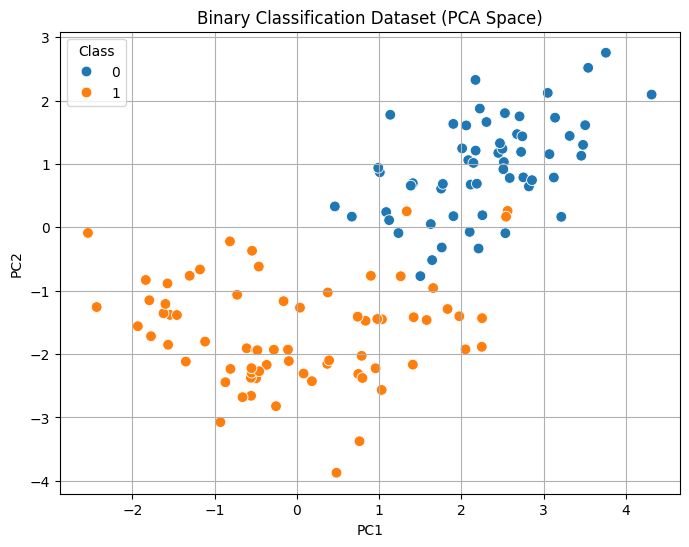

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_bin[:, 0],
    y=X_bin[:, 1],
    hue=y_bin,
    palette=["tab:blue", "tab:orange"],
    s=60
)

plt.title("Binary Classification Dataset (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class")
plt.grid(True)
plt.show()


##  Why Binary Classification?

By reducing the problem to two classes:
- The decision boundary becomes a **single curve**
- Evolutionary behavior becomes easier to analyze
- Visual evidence of learning is much stronger

This setup closely mirrors classical evolutionary optimization problems,
where a single structure evolves under performance-driven selection.


##  Decision Boundary Representation

To apply evolutionary optimization, we must define **what is being evolved**.

In this project, each individual in the population represents a **decision boundary**
defined by a second-order polynomial function:

f(x, y) = a·x² + b·y² + c·x·y + d·x + e·y + f

Where:
- (x, y) are PCA-transformed data points
- a, b, c, d, e, f are real-valued parameters (genes)

Classification rule:
- If f(x, y) ≥ 0 → Class 1
- If f(x, y) < 0 → Class 0

This representation allows:
- Non-linear decision boundaries
- Continuous parameter evolution
- Clear interpretability of solutions


In [9]:
def decision_function(X, params):
    """
    Computes decision values for input points X using polynomial parameters.
    
    Parameters:
    - X: array of shape (n_samples, 2)
    - params: list or array [a, b, c, d, e, f]
    
    Returns:
    - decision values (n_samples,)
    """
    a, b, c, d, e, f = params
    x = X[:, 0]
    y = X[:, 1]
    
    return (
        a * x**2 +
        b * y**2 +
        c * x * y +
        d * x +
        e * y +
        f
    )


In [10]:
def predict(X, params):
    """
    Predict class labels using the decision function.
    """
    scores = decision_function(X, params)
    return (scores >= 0).astype(int)


In [11]:
# Generate chromosome
random_params = np.random.uniform(-1, 1, size=6)

y_pred_random = predict(X_bin, random_params)

# Compute accuracy
random_accuracy = accuracy_score(y_bin, y_pred_random)

print("Random boundary accuracy:", round(random_accuracy, 3))
print("Random parameters:", random_params)


Random boundary accuracy: 0.746
Random parameters: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096]


##  Observation

At this stage:
- Accuracy may already be moderately high due to partial class separability
- The decision boundary is still **random and non-optimized**
- Performance is unstable and not generalizable
- This serves as a **baseline before evolutionary refinement**


In [12]:
accs = []
for _ in range(50):
    params = np.random.uniform(-1, 1, size=6)
    accs.append(accuracy_score(y_bin, predict(X_bin, params)))

print("Random accuracy range:", round(min(accs), 3), "-", round(max(accs), 3))
print("Mean random accuracy:", round(np.mean(accs), 3))


Random accuracy range: 0.085 - 0.954
Mean random accuracy: 0.509


##  Fitness Function and Population Initialization

To simulate natural selection, we define a **fitness function** that evaluates
how well each individual (decision boundary) performs on the classification task.

Fitness is defined as:
- **Classification accuracy** on the binary dataset

A population of randomly initialized individuals is then evaluated,
forming the starting point for evolutionary optimization.


In [13]:
def fitness_function(params, X, y):
    """
    Computes fitness (accuracy) of an individual.
    """
    y_pred = predict(X, params)
    return accuracy_score(y, y_pred)


In [14]:
def initialize_population(pop_size, param_bounds):
    """
    Initialize a population of individuals.
    
    pop_size: number of individuals
    param_bounds: list of (min, max) tuples for each gene
    """
    population = []
    for _ in range(pop_size):
        individual = np.array([
            np.random.uniform(low, high) 
            for (low, high) in param_bounds
        ])
        population.append(individual)
    return population


In [15]:
# GA parameters
POPULATION_SIZE = 30
PARAM_BOUNDS = [(-1, 1)] * 6  # bounds for a, b, c, d, e, f

# Initialize population
population = initialize_population(POPULATION_SIZE, PARAM_BOUNDS)

# Evaluate initial population
fitness_scores = [fitness_function(ind, X_bin, y_bin) for ind in population]

print("Initial population fitness:")
print("  Max:", round(max(fitness_scores), 3))
print("  Mean:", round(np.mean(fitness_scores), 3))
print("  Min:", round(min(fitness_scores), 3))


Initial population fitness:
  Max: 0.962
  Mean: 0.523
  Min: 0.108


##  Expected Outcome

The initial population should display:
- A wide range of fitness values
- Mean fitness close to random baseline
- A few high-performing individuals by chance

This diversity is essential for effective evolutionary search.


##  Selection and Crossover

Once fitness has been evaluated, the next evolutionary steps are:

### 🔹 Selection
High-performing individuals are more likely to reproduce.
We use **tournament selection**, which:
- Maintains diversity
- Avoids premature convergence
- Is simple and effective

### 🔹 Crossover
Two parent individuals exchange genetic material to create offspring.
This allows:
- Reuse of good partial solutions
- Exploration of new regions in the search space

Together, these steps transform random search into **directed evolution**.


In [16]:
def tournament_selection(population, fitness_scores, tournament_size=3):
    """
    Selects one individual using tournament selection.
    """
    selected_indices = np.random.choice(
        len(population), 
        size=tournament_size, 
        replace=False
    )
    
    best_index = selected_indices[0]
    for idx in selected_indices:
        if fitness_scores[idx] > fitness_scores[best_index]:
            best_index = idx
            
    return population[best_index]


In [17]:
def crossover(parent1, parent2, crossover_rate=0.9):
    """
    Performs uniform crossover between two parents.
    """
    if np.random.rand() > crossover_rate:
        return parent1.copy(), parent2.copy()
    
    child1, child2 = parent1.copy(), parent2.copy()
    
    for i in range(len(parent1)):
        if np.random.rand() < 0.5:
            child1[i], child2[i] = child2[i], child1[i]
    
    return child1, child2


In [18]:
# Select two parents
parent_a = tournament_selection(population, fitness_scores)
parent_b = tournament_selection(population, fitness_scores)

# Apply crossover
child_a, child_b = crossover(parent_a, parent_b)

print("Parent A:", parent_a)
print("Parent B:", parent_b)
print("\nChild A:", child_a)
print("Child B:", child_b)


Parent A: [-0.94929851  0.92529683  0.67196024  0.39194841 -0.18209411 -0.65341136]
Parent B: [ 0.90973056  0.47579383  0.10870811  0.22344149 -0.16079988 -0.50453802]

Child A: [-0.94929851  0.92529683  0.67196024  0.39194841 -0.18209411 -0.65341136]
Child B: [ 0.90973056  0.47579383  0.10870811  0.22344149 -0.16079988 -0.50453802]


##  Why Selection + Crossover?

- Selection ensures that **better solutions survive**
- Crossover allows good traits to **combine and propagate**
- Random guessing is replaced by **guided exploration**

At this point, the algorithm has all the ingredients of natural evolution,
except for one: **mutation**.


##  Mutation Operator

While selection and crossover exploit existing good solutions,
**mutation introduces novelty** into the population.

Mutation:
- Randomly perturbs genes with a small probability
- Prevents premature convergence
- Enables exploration of unseen regions of the search space

In biological terms, mutation is rare but essential for long-term evolution.


In [19]:
def mutate(individual, mutation_rate=0.1, mutation_scale=0.2, param_bounds=None):
    """
    Mutates an individual by adding small noise to genes.
    
    mutation_rate: probability of mutating each gene
    mutation_scale: standard deviation of mutation noise
    param_bounds: list of (min, max) tuples to clip values
    """
    mutated = individual.copy()
    
    for i in range(len(mutated)):
        if np.random.rand() < mutation_rate:
            mutated[i] += np.random.normal(0, mutation_scale)
            if param_bounds is not None:
                low, high = param_bounds[i]
                mutated[i] = np.clip(mutated[i], low, high)
    
    return mutated


In [20]:
original = population[0]
mutated = mutate(original, param_bounds=PARAM_BOUNDS)

print("Original individual:", original)
print("Mutated individual :", mutated)


Original individual: [ 0.0326007  -0.35408705  0.59037239 -0.4583355  -0.12205716 -0.84308724]
Mutated individual : [ 0.0326007  -0.35408705  0.59037239 -0.4583355  -0.12205716 -0.84308724]


##  Why Mutation Matters

Without mutation:
- The population would eventually become identical
- Evolution would stagnate
- The algorithm could get stuck in local optima

Mutation ensures that:
- New boundary shapes continue to appear
- Rare but valuable traits can emerge
- Evolution remains dynamic and adaptive


##  Evolutionary Loop

With all genetic operators defined, we now combine them into a full
**Genetic Algorithm loop**.

At each generation:
1. Evaluate fitness of the population
2. Select parents based on fitness
3. Apply crossover and mutation
4. Form a new population
5. Track best and average fitness

This process simulates **natural selection over generations**.


In [21]:
def run_genetic_algorithm(
    X, y,
    population_size=30,
    generations=40,
    crossover_rate=0.9,
    mutation_rate=0.1,
    mutation_scale=0.2,
    tournament_size=3,
    param_bounds=None
):
    # Initialize population
    population = initialize_population(population_size, param_bounds)
    
    best_fitness_history = []
    mean_fitness_history = []
    
    best_individual = None
    best_fitness = -np.inf
    
    for gen in range(generations):
        # Evaluate fitness
        fitness_scores = [fitness_function(ind, X, y) for ind in population]
        
        gen_best = max(fitness_scores)
        gen_mean = np.mean(fitness_scores)
        
        best_fitness_history.append(gen_best)
        mean_fitness_history.append(gen_mean)
        
        # Update global best
        if gen_best > best_fitness:
            best_fitness = gen_best
            best_individual = population[np.argmax(fitness_scores)]
        
        # Create next generation
        new_population = []
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitness_scores, tournament_size)
            parent2 = tournament_selection(population, fitness_scores, tournament_size)
            
            child1, child2 = crossover(parent1, parent2, crossover_rate)
            
            child1 = mutate(child1, mutation_rate, mutation_scale, param_bounds)
            child2 = mutate(child2, mutation_rate, mutation_scale, param_bounds)
            
            new_population.extend([child1, child2])
        
        population = new_population[:population_size]
        
        print(
            f"Generation {gen+1:02d} | "
            f"Best fitness: {gen_best:.3f} | "
            f"Mean fitness: {gen_mean:.3f}"
        )
    
    return best_individual, best_fitness, best_fitness_history, mean_fitness_history


In [22]:
best_individual, best_fitness, best_hist, mean_hist = run_genetic_algorithm(
    X_bin,
    y_bin,
    population_size=30,
    generations=40,
    crossover_rate=0.9,
    mutation_rate=0.1,
    mutation_scale=0.2,
    tournament_size=3,
    param_bounds=PARAM_BOUNDS
)

print("\nBest evolved fitness:", round(best_fitness, 3))
print("Best evolved parameters:", best_individual)


Generation 01 | Best fitness: 0.815 | Mean fitness: 0.443
Generation 02 | Best fitness: 0.862 | Mean fitness: 0.580
Generation 03 | Best fitness: 0.900 | Mean fitness: 0.680
Generation 04 | Best fitness: 0.962 | Mean fitness: 0.806
Generation 05 | Best fitness: 0.969 | Mean fitness: 0.881
Generation 06 | Best fitness: 0.969 | Mean fitness: 0.931
Generation 07 | Best fitness: 0.977 | Mean fitness: 0.949
Generation 08 | Best fitness: 0.977 | Mean fitness: 0.959
Generation 09 | Best fitness: 0.977 | Mean fitness: 0.962
Generation 10 | Best fitness: 0.977 | Mean fitness: 0.966
Generation 11 | Best fitness: 0.977 | Mean fitness: 0.968
Generation 12 | Best fitness: 0.977 | Mean fitness: 0.964
Generation 13 | Best fitness: 0.977 | Mean fitness: 0.970
Generation 14 | Best fitness: 0.977 | Mean fitness: 0.970
Generation 15 | Best fitness: 0.977 | Mean fitness: 0.969
Generation 16 | Best fitness: 0.977 | Mean fitness: 0.968
Generation 17 | Best fitness: 0.977 | Mean fitness: 0.966
Generation 18 

##  Observing Evolution

During evolution, you should observe:
- Best fitness steadily increasing or stabilizing
- Mean fitness rising over generations
- Reduced variance between individuals
- Convergence toward high-performing boundaries

These trends indicate **successful evolutionary optimization**.


##  Visualizing Evolutionary Progress

To understand how evolution improved solutions over time,
we visualize:

- **Best fitness per generation**
- **Mean population fitness per generation**

These curves provide clear evidence of:
- Selection pressure
- Population-wide improvement
- Convergence behavior

Such plots are standard in evolutionary computation research.


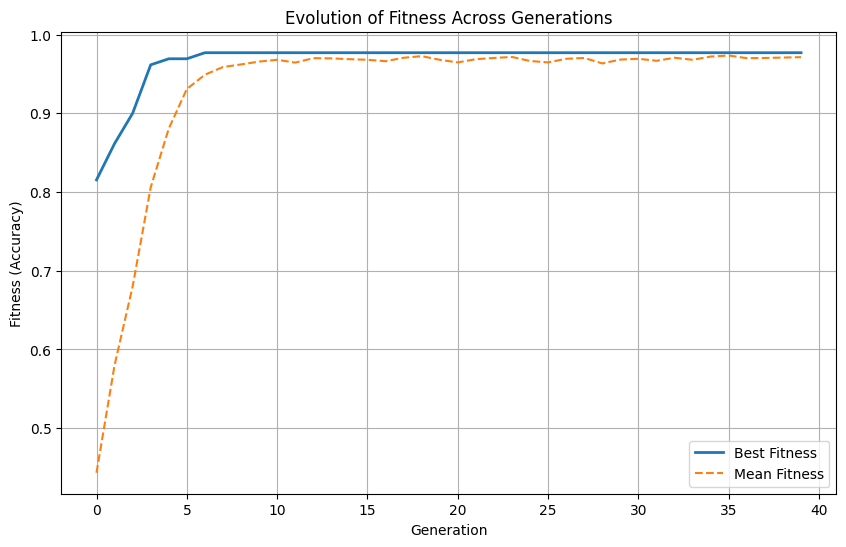

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(best_hist, label="Best Fitness", linewidth=2)
plt.plot(mean_hist, label="Mean Fitness", linestyle="--")

plt.xlabel("Generation")
plt.ylabel("Fitness (Accuracy)")
plt.title("Evolution of Fitness Across Generations")
plt.legend()
plt.grid(True)

plt.show()


##  Interpretation of Results

From the fitness curves, we observe:

- Rapid improvement in early generations due to strong selection pressure
- Gradual convergence as the population stabilizes
- Small oscillations caused by mutation and stochastic selection
- Near-optimal performance achieved without gradient-based training

The close alignment of best and mean fitness indicates
that the population has largely converged to high-quality solutions.


##  Visualizing the Evolved Decision Boundary

To understand *what evolution has actually learned*, we visualize the
**final evolved decision boundary** in the PCA space.

By plotting:
- The data points
- The boundary defined by the best evolved parameters

we can directly observe how evolution has shaped a non-linear separator
to distinguish between the two classes.

This visualization provides **interpretability**, which is often missing
in complex machine learning models.


In [24]:
x_min, x_max = X_bin[:, 0].min() - 1, X_bin[:, 0].max() + 1
y_min, y_max = X_bin[:, 1].min() - 1, X_bin[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# Stack grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]


In [25]:
Z = decision_function(grid_points, best_individual)
Z = Z.reshape(xx.shape)


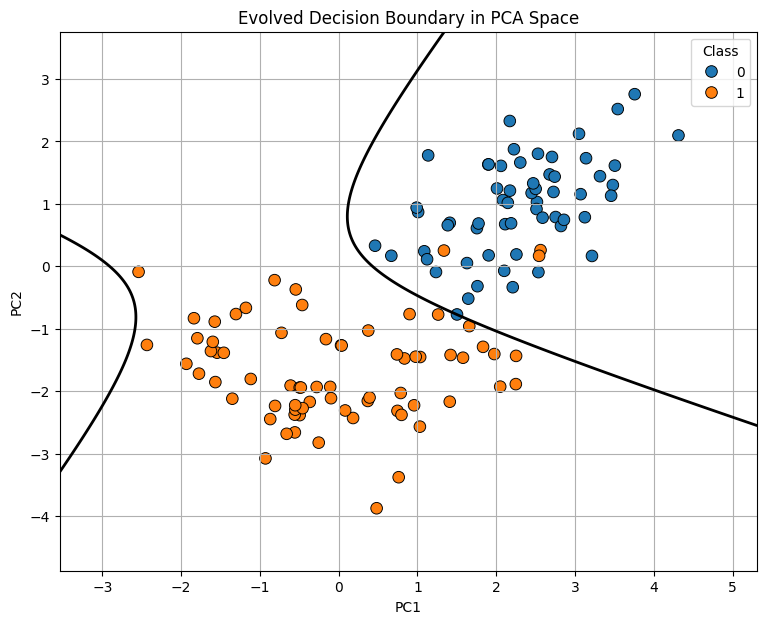

In [26]:
plt.figure(figsize=(9, 7))

# Plot decision boundary (f(x, y) = 0)
plt.contour(
    xx, yy, Z,
    levels=[0],
    linewidths=2,
    colors="black"
)

sns.scatterplot(
    x=X_bin[:, 0],
    y=X_bin[:, 1],
    hue=y_bin,
    palette=["tab:blue", "tab:orange"],
    s=70,
    edgecolor="k"
)

plt.title("Evolved Decision Boundary in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class")
plt.grid(True)

plt.show()


##  Interpretation of the Evolved Boundary

From the visualization, we observe:

- A smooth, non-linear decision boundary
- Clear separation between most data points
- Boundary shape that adapts to class geometry
- No human-designed rules or gradients involved

This boundary emerged purely through **fitness-driven evolution**,
demonstrating that Genetic Algorithms can discover effective
classification structures in a black-box manner.
